ARTI308 - Machine Learning

# Lab 4: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

![step2.png](step2.png)

In this lab, we will apply practical preprocessing techniques step by step.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Load Dataset

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("daily_internet_usage_by_age_group.csv")
df.head(10)

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type
0,1,2024-04-02,15,13-18,2.2,3.7,2.4,8.3,Mobile,WiFi
1,2,2024-06-07,13,13-18,1.1,6.9,2.1,10.1,Tablet,WiFi
2,3,2024-04-03,21,19-25,1.3,5.7,1.6,8.6,Tablet,WiFi
3,4,2024-10-02,35,26-35,2.5,5.0,2.0,9.5,Mobile,WiFi
4,5,2024-10-05,49,46-60,0.2,6.3,2.8,9.3,Laptop,WiFi
5,6,2024-11-22,44,36-45,1.9,3.8,2.5,8.2,Tablet,Mobile Data
6,7,2024-04-02,47,46-60,3.2,5.4,2.9,11.5,Mobile,Mobile Data
7,8,2024-04-02,22,19-25,3.8,6.9,2.9,13.6,Laptop,Mobile Data
8,9,2024-02-13,16,13-18,3.9,6.7,3.3,13.9,Tablet,WiFi
9,10,2024-09-07,14,13-18,0.5,6.7,1.0,8.2,Laptop,WiFi


## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.
For example:
- `Date` should be datetime
- `Revenue` should be numeric

In [3]:
df.dtypes

user_id                  int64
date                       str
age                      int64
age_group                  str
social_media_hours     float64
work_or_study_hours    float64
entertainment_hours    float64
total_screen_time      float64
primary_device             str
internet_type              str
dtype: object

The only problem is date. It is a string (str) but should be datetime.

### 2.2 Convert Incorrect Data Types
We will convert:
- `Date` to datetime format

In [5]:
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)
df.dtypes

user_id                         int64
date                   datetime64[us]
age                             int64
age_group                         str
social_media_hours            float64
work_or_study_hours           float64
entertainment_hours           float64
total_screen_time             float64
primary_device                    str
internet_type                     str
dtype: object

Now `Date` is correctly stored as *datetime64*.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [6]:
df.isna().sum()

user_id                0
date                   0
age                    0
age_group              0
social_media_hours     0
work_or_study_hours    0
entertainment_hours    0
total_screen_time      0
primary_device         0
internet_type          0
dtype: int64

The output shows whether any column contains missing values.
If all values are zero, the dataset is complete.
If any column contains missing values, we must handle them.

### 3.2 Demonstration: Introduce Artificial Missing Values
### Why?

Since our dataset has no missing values, we introduce artificial ones *for learning purposes*.
We’ll use total_screen_time.

In [7]:
df_missing = df.copy()
df_missing.loc[0:5, 'total_screen_time'] = np.nan
df_missing.isna().sum()

user_id                0
date                   0
age                    0
age_group              0
social_media_hours     0
work_or_study_hours    0
entertainment_hours    0
total_screen_time      6
primary_device         0
internet_type          0
dtype: int64

Now the total_screen_time column contains missing values.

In [11]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)
#Shape stays same because we didn’t remove rows yet.

Original shape:  (2800, 10)
After removing some values:  (2800, 10)


In [9]:
df_missing.head(10)

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type
0,1,2024-02-04,15,13-18,2.2,3.7,2.4,NaN,Mobile,WiFi
1,2,2024-07-06,13,13-18,1.1,6.9,2.1,NaN,Tablet,WiFi
2,3,2024-03-04,21,19-25,1.3,5.7,1.6,NaN,Tablet,WiFi
3,4,2024-02-10,35,26-35,2.5,5.0,2.0,NaN,Mobile,WiFi
4,5,2024-05-10,49,46-60,0.2,6.3,2.8,NaN,Laptop,WiFi
5,6,2024-11-22,44,36-45,1.9,3.8,2.5,NaN,Tablet,Mobile Data
6,7,2024-02-04,47,46-60,3.2,5.4,2.9,11.5,Mobile,Mobile Data
7,8,2024-02-04,22,19-25,3.8,6.9,2.9,13.6,Laptop,Mobile Data
8,9,2024-02-13,16,13-18,3.9,6.7,3.3,13.9,Tablet,WiFi
9,10,2024-07-09,14,13-18,0.5,6.7,1.0,8.2,Laptop,WiFi


### Strategy 1: Remove Records?
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

This method is acceptable when missing values are extremely few like here, but it still causes permanent data loss. Since the missing values exist only in one column, removing entire rows is inefficient.

### Strategy 2: Mean Imputation?

![Mean.png](Mean.png)

The mean represents the average value.
It is commonly used for normally distributed data.

Mean imputation is less suitable because it is sensitive to outliers and may produce unrealistic replacement values.

### Strategy 3: Median Imputation

![median_formula_2.png](median_formula_2.png)
The median is more robust to outliers than the mean.
It is preferred for skewed data.

In [21]:
df_imputed = df_missing.copy()

df_imputed['total_screen_time'] = df_imputed['total_screen_time'].fillna(
    df_imputed['total_screen_time'].median()
)

In [24]:
df_imputed.isna().sum()

user_id                0
date                   0
age                    0
age_group              0
social_media_hours     0
work_or_study_hours    0
entertainment_hours    0
total_screen_time      0
primary_device         0
internet_type          0
dtype: int64

In [25]:
df_imputed.head(10)

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type
0,1,2024-02-04,15,13-18,2.2,3.7,2.4,8.1,Mobile,WiFi
1,2,2024-07-06,13,13-18,1.1,6.9,2.1,8.1,Tablet,WiFi
2,3,2024-03-04,21,19-25,1.3,5.7,1.6,8.1,Tablet,WiFi
3,4,2024-02-10,35,26-35,2.5,5.0,2.0,8.1,Mobile,WiFi
4,5,2024-05-10,49,46-60,0.2,6.3,2.8,8.1,Laptop,WiFi
5,6,2024-11-22,44,36-45,1.9,3.8,2.5,8.1,Tablet,Mobile Data
6,7,2024-02-04,47,46-60,3.2,5.4,2.9,11.5,Mobile,Mobile Data
7,8,2024-02-04,22,19-25,3.8,6.9,2.9,13.6,Laptop,Mobile Data
8,9,2024-02-13,16,13-18,3.9,6.7,3.3,13.9,Tablet,WiFi
9,10,2024-07-09,14,13-18,0.5,6.7,1.0,8.2,Laptop,WiFi


Missing values are replaced with the middle value.
This approach is safer when data contains extreme values.

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using IQR method.

![IQR.png](IQR.png)

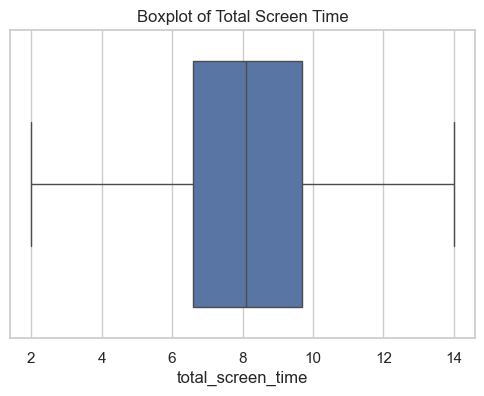

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x=df_imputed['total_screen_time'])
plt.title("Boxplot of Total Screen Time")
plt.show()

Points outside the whiskers represent potential outliers.
These extreme revenue values may influence model predictions.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [27]:
Q1 = df_imputed['total_screen_time'].quantile(0.25)
Q3 = df_imputed['total_screen_time'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_imputed[
    (df_imputed['total_screen_time'] < lower) |
    (df_imputed['total_screen_time'] > upper)
]

outliers.head(15)

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type


The output displays records considered extreme based on statistical boundaries.
These may be valid high-value transactions or potential data errors.

### Remove Outliers
We remove values outside the acceptable range.

In [28]:
df_no_outliers = df_imputed[
    (df_imputed['total_screen_time'] >= lower) &
    (df_imputed['total_screen_time'] <= upper)
]

print("Original shape:", df_imputed.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (2800, 10)
After removing outliers: (2800, 10)


The dataset size is slightly reduced.
Removing outliers reduces distortion but may also remove important rare events.

#### Important Note on Removing Outliers

Not all outliers are errors.

Some extreme values may represent rare but important real-world events.  
For example, in a sales dataset, a very large transaction might correspond to a bulk corporate order or a seasonal promotion.  

If we remove such values blindly, we may lose valuable information and bias the analysis.

Before removing outliers, we should always ask:
- Is this value a data entry mistake?
- Or is it a valid but rare observation?

### Capping Outliers (Percentile Method)
Instead of removing outliers, we replace extreme values with percentile limits.

![percentile.png](percentile.png)

In [29]:
lower_cap = df_imputed['total_screen_time'].quantile(0.05)
upper_cap = df_imputed['total_screen_time'].quantile(0.95)

df_capped = df_imputed.copy()

df_capped['total_screen_time'] = df_capped['total_screen_time'].clip(
    lower_cap,
    upper_cap
)

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.

It works using the formula:
![min_max.png](min_max.png)

This method preserves the original distribution shape and relative ordering of values.

Min-Max normalization is especially useful for distance-based models such as:
- K-Nearest Neighbors (KNN)
- K-Means clustering
- Support Vector Machines (SVM)

These models rely on distance calculations, and if features are on very different scales, one feature can dominate the distance computation.

In [3]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
# daily internet usage data
data = {
    'Day': ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
    'Internet_Hours': [3.9, 0.5, 1.7, 2.2, 2.2, 2.3, 3.6]
}

df = pd.DataFrame(data)
df.head()

,Day,Internet_Hours
0,Mon,3.9
1,Tue,0.5
2,Wed,1.7
3,Thu,2.2
4,Fri,2.2


In [4]:
scaler = MinMaxScaler()
df_scaled = df.copy()

df_scaled['Internet_Hours'] = scaler.fit_transform(df_scaled[['Internet_Hours']])
df_scaled.head()

,Day,Internet_Hours
0,Mon,1.000000
1,Tue,0.000000
2,Wed,0.352941
3,Thu,0.500000
4,Fri,0.500000


After applying Min-Max normalization, all numerical values are scaled to the range between 0 and 1.

The smallest value in each feature becomes 0, and the largest becomes 1.
All other values are proportionally mapped between these two limits.

Importantly, normalization does NOT change the relative relationships between data points.
If one transaction originally had higher revenue than another, it will still have a higher normalized value.

### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

This is done by subtracting the mean and dividing by the standard deviation:

![zscore.png](zscore.png)

This method keeps the shape of the distribution but rescales it around zero.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df.copy()

df_standardized['Internet_Hours'] = scaler.fit_transform(df_standardized[['Internet_Hours']])
df_standardized.head()

,Day,Internet_Hours
0,Mon,1.469756
1,Tue,-1.739436
2,Wed,-0.606780
3,Thu,-0.134840
4,Fri,-0.134840


After standardization, the numerical features are centered around 0.
Values above the original mean become **positive**, and values below the mean become **negative**.

The standard deviation of each feature becomes approximately 1, meaning the spread of the data is standardized.

This transformation is especially useful for:
- Linear regression
- Support Vector Machines (SVM)
- PCA

Because these models assume features are centered and scaled similarly.

## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)

In such cases, dimensionality reduction using PCA is meaningful 
because we can combine correlated features into fewer components.

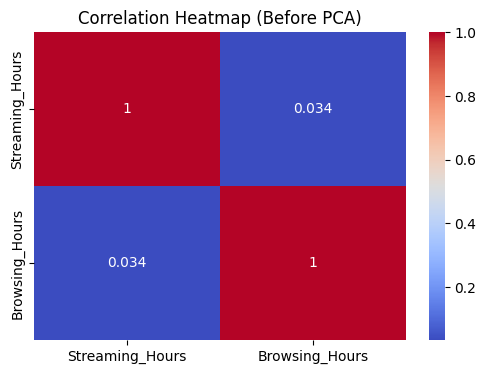

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Example daily internet usage (hours) for multiple activities
data = {
    'Day': ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
    'Streaming_Hours': [2.5, 3.2, 4.0, 1.8, 3.5, 2.0, 4.5],
    'Browsing_Hours': [3.9, 0.5, 1.7, 2.2, 2.2, 2.3, 3.6]
}

df = pd.DataFrame(data)
df.head()
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['Streaming_Hours', 'Browsing_Hours']].copy()
df_standardized[:] = scaler.fit_transform(df_standardized)
df_standardized.head()
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

The heatmap shows the correlation between the numerical features:

- The diagonal values are 1 because each feature is perfectly correlated with itself.
- The correlation between `Amount` and `Boxes Shipped` is approximately *-0.013*.

A correlation value close to 0 indicates that there is almost **NO linear** relationship between the two features.

This means that `Amount` and `Boxes Shipped` do not move together in a predictable linear pattern.

Since PCA is most useful when features are strongly correlated, 
the benefit of dimensionality reduction in this case may be limited.

Therefore, applying PCA here is mainly for demonstration purposes rather than necessity.

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:

- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance, while being orthogonal (perpendicular) to PC1.

This allows us to reduce dimensionality while retaining most of the important information in the data.

Suppose we have two features:

X1 = Streaming Hours
X2 = Browsing Hours

If users who stream more also browse more, the points form a diagonal pattern.

PCA finds the direction where usage varies the most.

That direction becomes Principal Component 1 (PC1).

If most variation lies along PC1, we can reduce:

2 features → 1 feature

while keeping most of the information.

In [9]:
from sklearn.decomposition import PCA
#We use the standardized internet usage features created earlier.
X = df_standardized[['Streaming_Hours', 'Browsing_Hours']]
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.5170986 0.4829014]


The `Explained Variance Ratio` indicates how much of the total information (variance) is captured by each principal component.

For example:
- If PC1 explains 85% of the variance, it means that one new feature already summarizes most of the dataset's information.
- If PC1 and PC2 together explain nearly 100%, then very little information is lost.

When most of the variance is captured by fewer components, dimensionality reduction is considered effective.

This helps simplify models, reduce computational cost, and sometimes improve generalization performance.

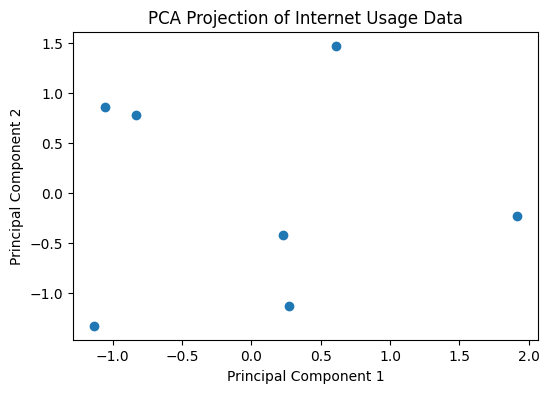

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(principal_components[:,0], principal_components[:,1])

plt.title("PCA Projection of Internet Usage Data")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

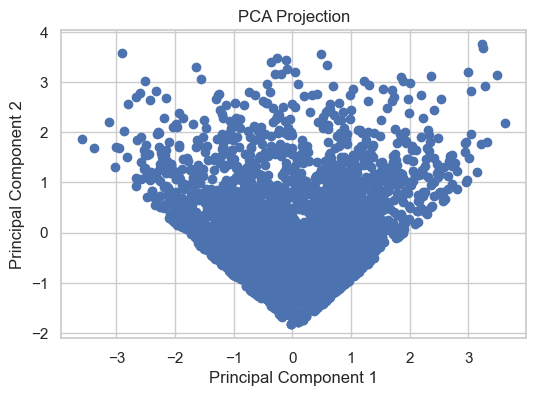

In [25]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Each point in this plot represents one sales transaction.

The axes no longer represent the original features (Amount and Boxes Shipped).
Instead:

- The horizontal axis represents Principal Component 1 (PC1).
- The vertical axis represents Principal Component 2 (PC2).

PC1 captures the direction of maximum variance in the data.
PC2 captures the second most important direction, perpendicular to PC1.

The spread of points along the horizontal direction indicates how much variation is captured by PC1.
If most of the spread appears horizontally, it suggests that PC1 captures most of the dataset's information.

This projection allows us to visualize high-dimensional data in a lower-dimensional space.

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of lab 4.